In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('ventas_tienda_online.csv')
df

,Fecha,Producto,Categoría,Cantidad,Precio,Ingresos
0,2023-02-02,Rompecabezas,Juguetes,9,5.67,51.03
1,2023-05-29,Jeans,Ropa,6,18.86,113.16
2,2023-03-24,Teléfono,Electrónica,4,60.42,241.68
3,2023-05-14,Mesa,Hogar,6,79.57,477.42
4,2023-02-17,Rompecabezas,Juguetes,8,20.36,162.88
...,...,...,...,...,...,...
995,2023-05-24,Jeans,Ropa,8,25.90,207.20
996,2023-02-07,Auriculares,Electrónica,3,41.60,124.80
997,2023-06-06,Mesa,Hogar,7,10.45,73.15
998,2023-07-23,Muñeca,Juguetes,10,67.88,678.80


In [9]:
print(df.head())


        Fecha      Producto    Categoría  Cantidad  Precio  Ingresos
0  2023-02-02  Rompecabezas     Juguetes         9    5.67     51.03
1  2023-05-29         Jeans         Ropa         6   18.86    113.16
2  2023-03-24      Teléfono  Electrónica         4   60.42    241.68
3  2023-05-14          Mesa        Hogar         6   79.57    477.42
4  2023-02-17  Rompecabezas     Juguetes         8   20.36    162.88


In [7]:
display(df.tail())

,Fecha,Producto,Categoría,Cantidad,Precio,Ingresos
995,2023-05-24,Jeans,Ropa,8,25.90,207.20
996,2023-02-07,Auriculares,Electrónica,3,41.60,124.80
997,2023-06-06,Mesa,Hogar,7,10.45,73.15
998,2023-07-23,Muñeca,Juguetes,10,67.88,678.80
999,2023-05-21,Biografía,Libros,3,30.14,90.42


In [8]:
display(df.describe())

,Cantidad,Precio,Ingresos
count,1000.000000,1000.000000,1000.000000
mean,5.565000,51.673630,287.516030
std,2.918954,27.500659,230.545971
min,1.000000,5.060000,6.820000
25%,3.000000,27.887500,96.285000
50%,6.000000,51.480000,230.125000
75%,8.000000,74.835000,417.975000
max,10.000000,99.900000,990.200000


In [10]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Fecha      1000 non-null   object 
 1   Producto   1000 non-null   object 
 2   Categoría  1000 non-null   object 
 3   Cantidad   1000 non-null   int64  
 4   Precio     1000 non-null   float64
 5   Ingresos   1000 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 47.0+ KB


None

In [13]:
df['Fecha']=pd.to_datetime(df['Fecha'])
df

,Fecha,Producto,Categoría,Cantidad,Precio,Ingresos
0,2023-02-02,Rompecabezas,Juguetes,9,5.67,51.03
1,2023-05-29,Jeans,Ropa,6,18.86,113.16
2,2023-03-24,Teléfono,Electrónica,4,60.42,241.68
3,2023-05-14,Mesa,Hogar,6,79.57,477.42
4,2023-02-17,Rompecabezas,Juguetes,8,20.36,162.88
...,...,...,...,...,...,...
995,2023-05-24,Jeans,Ropa,8,25.90,207.20
996,2023-02-07,Auriculares,Electrónica,3,41.60,124.80
997,2023-06-06,Mesa,Hogar,7,10.45,73.15
998,2023-07-23,Muñeca,Juguetes,10,67.88,678.80


In [22]:
df['Mes'] = df['Fecha'].dt.to_period('M')
df


,Fecha,Producto,Categoría,Cantidad,Precio,Ingresos,Mes
0,2023-02-02,Rompecabezas,Juguetes,9,5.67,51.03,2023-02
1,2023-05-29,Jeans,Ropa,6,18.86,113.16,2023-05
2,2023-03-24,Teléfono,Electrónica,4,60.42,241.68,2023-03
3,2023-05-14,Mesa,Hogar,6,79.57,477.42,2023-05
4,2023-02-17,Rompecabezas,Juguetes,8,20.36,162.88,2023-02
...,...,...,...,...,...,...,...
995,2023-05-24,Jeans,Ropa,8,25.90,207.20,2023-05
996,2023-02-07,Auriculares,Electrónica,3,41.60,124.80,2023-02
997,2023-06-06,Mesa,Hogar,7,10.45,73.15,2023-06
998,2023-07-23,Muñeca,Juguetes,10,67.88,678.80,2023-07


In [24]:
ventas_mensuales = df.groupby('Mes')['Ingresos'].sum()
display(ventas_mensuales)

,Ingresos
Mes,
2023-01,21829.02
2023-02,24017.90
2023-03,20909.08
2023-04,25800.14
2023-05,23245.42
2023-06,28238.73
2023-07,21134.99
2023-08,25590.36
2023-09,24434.62


In [28]:
cantidad_x_producto = df.groupby('Producto')['Cantidad'].sum()
display(cantidad_x_producto)

,Cantidad
Producto,
Auriculares,348
Biografía,347
Camiseta,337
Chaqueta,388
Ensayo,351
Jeans,373
Lámpara,422
Mesa,345
Muñeca,358


In [32]:
ventas_x_categoria = df.groupby('Categoría').agg(Total_Cantidad=('Cantidad', 'sum'), Total_Ingresos=('Ingresos', 'sum'))
display(ventas_x_categoria)

,Total_Cantidad,Total_Ingresos
Categoría,,
Electrónica,1040,52500.46
Hogar,1202,63962.16
Juguetes,1205,64285.84
Libros,1020,52849.58
Ropa,1098,53917.99


In [35]:
df.to_csv('registro_ventas.csv', index=False)
df

,Fecha,Producto,Categoría,Cantidad,Precio,Ingresos,Mes
0,2023-02-02,Rompecabezas,Juguetes,9,5.67,51.03,2023-02
1,2023-05-29,Jeans,Ropa,6,18.86,113.16,2023-05
2,2023-03-24,Teléfono,Electrónica,4,60.42,241.68,2023-03
3,2023-05-14,Mesa,Hogar,6,79.57,477.42,2023-05
4,2023-02-17,Rompecabezas,Juguetes,8,20.36,162.88,2023-02
...,...,...,...,...,...,...,...
995,2023-05-24,Jeans,Ropa,8,25.90,207.20,2023-05
996,2023-02-07,Auriculares,Electrónica,3,41.60,124.80,2023-02
997,2023-06-06,Mesa,Hogar,7,10.45,73.15,2023-06
998,2023-07-23,Muñeca,Juguetes,10,67.88,678.80,2023-07


/tmp/ipykernel_42186/534194521.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Categoría', y='Total_Ingresos', data=ventas_x_categoria.reset_index(), palette='pastel')


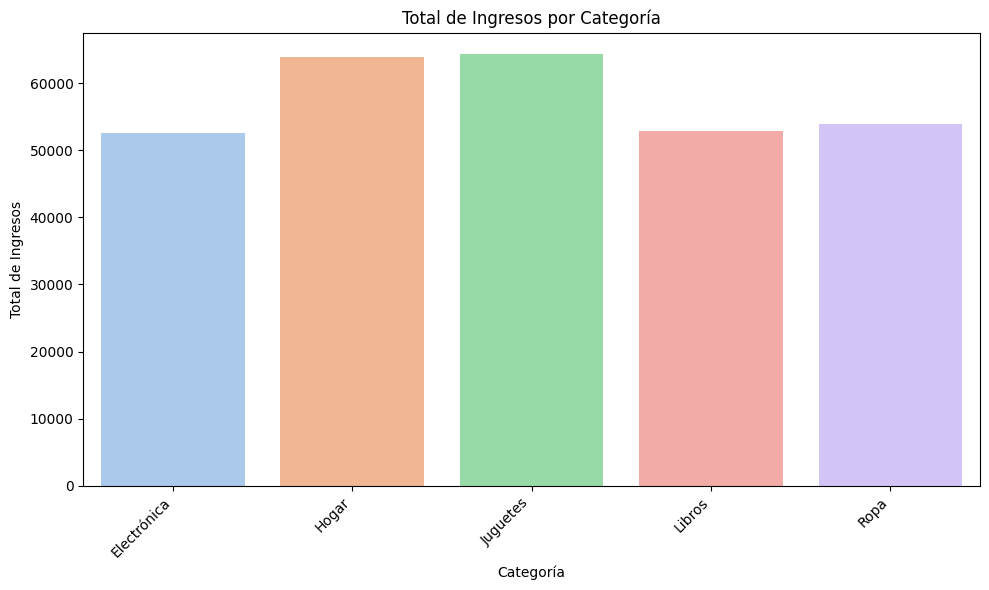

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the 'ventas_x_categoria' DataFrame is available
# If it's not already created from previous steps, we would recreate it here:
# ventas_x_categoria = df.groupby('Categoría').agg(Total_Cantidad=('Cantidad', 'sum'), Total_Ingresos=('Ingresos', 'sum')).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Categoría', y='Total_Ingresos', data=ventas_x_categoria.reset_index(), palette='pastel')
plt.title('Total de Ingresos por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Total de Ingresos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

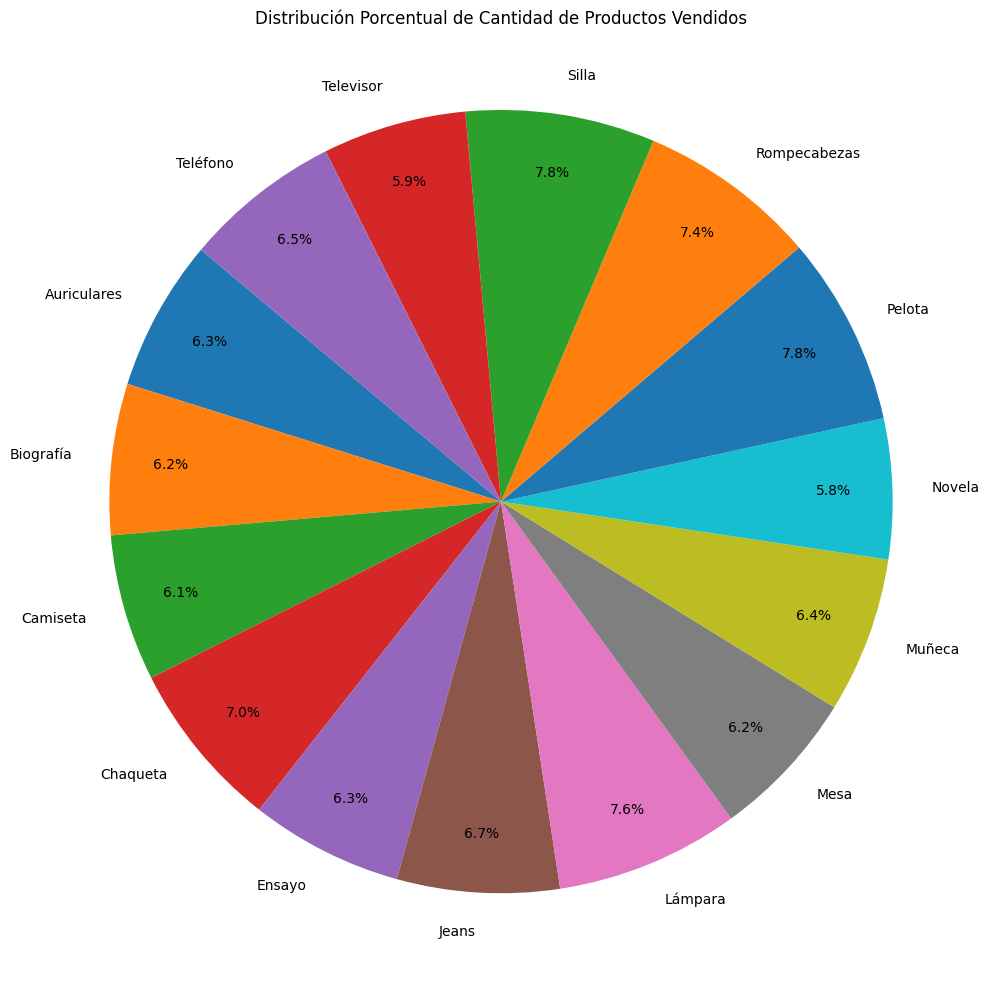

In [40]:
import matplotlib.pyplot as plt

# Calculate percentages for the pie chart
porcentaje = cantidad_x_producto / cantidad_x_producto.sum() * 100

# Create the pie chart
plt.figure(figsize=(10, 10)) # Make the figure square for a better looking pie chart
plt.pie(porcentaje, labels=cantidad_x_producto.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85) # autopct to show percentages, pctdistance to move them inwards
plt.title('Distribución Porcentual de Cantidad de Productos Vendidos')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()